# Sıcaklık ve Örnekleme Stratejileri ile Metin Üretimi

Bu notebook, dil modellerinde metin üretimi için kullanılan sıcaklık (temperature) ve örnekleme (sampling) stratejilerini gerçek verilerle uygulamalı olarak ele almaktadır.

**Veri Seti:** `kinguistics/shakespeare-plays` - Shakespeare oyunlarından metinler

**Kapsanan Konular:**
1. Veri setini indirme ve yükleme
2. Bigram modeli oluşturma
3. Greedy Decoding
4. Sıcaklık etkisi
5. Top-k Sampling
6. Top-p (Nucleus) Sampling
7. Stratejilerin karşılaştırılması
8. Olasılık dağılımı görselleştirilmesi

In [1]:
# Gerekli kütüphaneleri kur
!pip install numpy matplotlib pandas -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import random
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
print('Kütüphaneler başarıyla yüklendi!')

Kütüphaneler başarıyla yüklendi!


## 1. Veri Setini İndirme

Shakespeare oyunlarından oluşan metin veri setini Kaggle üzerinden indirip yüklüyoruz.

In [3]:
# Kaggle API ile veri setini indir
KAGGLE_AVAILABLE = False

try:
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    api.authenticate()
    KAGGLE_AVAILABLE = True
    print('Kaggle API başarıyla kimlik doğrulandı!')
except Exception as e:
    print(f'Kaggle API mevcut değil: {e}')
    print('Kaggle API anahtarı gerekli. ~/.kaggle/kaggle.json dosyasını oluşturun.')

# Veri setini indir
import zipfile
import glob
import os

if KAGGLE_AVAILABLE:
    try:
        api.dataset_download_files(
            'kinguistics/shakespeare-plays',
            path='./shakespeare_data',
            force=True,
            quiet=False
        )
        print('Veri seti indirildi.')
    except Exception as e:
        print(f'İndirme hatası: {e}')

# Veri setini yükle
text_data = None

try:
    # Zip dosyasını aç
    zip_files = glob.glob('./shakespeare_data/*.zip')
    if zip_files:
        for zf in zip_files:
            with zipfile.ZipFile(zf, 'r') as z:
                z.extractall('./shakespeare_data')

    # CSV dosyasını bul
    csv_files = glob.glob('./shakespeare_data/*.csv')
    if csv_files:
        df = pd.read_csv(csv_files[0])
        print(f'Veri seti yüklendi: {len(df)} satır')
        print(f'Sütunlar: {df.columns.tolist()}')

        # Metin sütununu bul
        text_col = None
        for col in df.columns:
            if 'text' in col.lower() or 'line' in col.lower() or 'play' in col.lower():
                text_col = col
                break
        if text_col is None:
            text_col = df.columns[-1]  # Son sütunu kullan

        text_data = ' '.join(df[text_col].dropna().astype(str).tolist())
except Exception as e:
    print(f'Yükleme hatası: {e}')

# Eğer veri yüklenemezse, örnek Shakespeare metni oluştur
if text_data is None or len(text_data) == 0:
    print('Örnek Shakespeare metni oluşturuluyor...')
    text_data = """
    To be, or not to be, that is the question:
    Whether 'tis nobler in the mind to suffer
    The slings and arrows of outrageous fortune,
    Or to take arms against a sea of troubles,
    And by opposing end them. To die: to sleep;
    No more; and by a sleep to say we end
    The heart-ache and the thousand natural shocks
    That flesh is heir to, 'tis a consummation
    Devoutly to be wish'd. To die, to sleep;
    To sleep: perchance to dream: ay, there's the rub;
    For in that sleep of death what dreams may come
    When we have shuffled off this mortal coil,
    Must give us pause: there's the respect
    That makes calamity of so long life;
    For who would bear the whips and scorns of time,
    The oppressor's wrong, the proud man's contumely,
    The pangs of despised love, the law's delay,
    The insolence of office and the spurns
    That patient merit of the unworthy takes,
    When he himself might his quietus make
    With a bare bodkin? who would fardels bear,
    To grunt and sweat under a weary life,
    But that the dread of something after death,
    The undiscover'd country from whose bourn
    No traveller returns, puzzles the will
    And makes us rather bear those ills we have
    Than fly to others that we know not of?
    Thus conscience does make cowards of us all;
    And thus the native hue of resolution
    Is sicklied o'er with the pale cast of thought,
    And enterprises of great pith and moment
    With this regard their currents turn awry,
    And lose the name of action.

    All the world's a stage,
    And all the men and women merely players:
    They have their exits and their entrances;
    And one man in his time plays many parts,
    His acts being seven ages.

    Friends, Romans, countrymen, lend me your ears;
    I come to bury Caesar, not to praise him.
    The evil that men do lives after them;
    The good is oft interred with their bones;
    So let it be with Caesar.

    Romeo, Romeo! wherefore art thou Romeo?
    Deny thy father and refuse thy name;
    Or, if thou wilt not, be but sworn my love,
    And I'll no longer be a Capulet.

    What's in a name? that which we call a rose
    By any other name would smell as sweet;
    """

# Metni temizle
text_data = text_data.strip()
print(f'\nToplam karakter sayısı: {len(text_data)}')
print(f'İlk 500 karakter:\n{text_data[:500]}')

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
Kaggle API mevcut değil: name 'exit' is not defined
Kaggle API anahtarı gerekli. ~/.kaggle/kaggle.json dosyasını oluşturun.
Örnek Shakespeare metni oluşturuluyor...

Toplam karakter sayısı: 2233
İlk 500 karakter:
To be, or not to be, that is the question:
    Whether 'tis nobler in the mind to suffer
    The slings and arrows of outrageous fortune,
    Or to take arms against a sea of troubles,
    And by opposing end them. To die: to sleep;
    No more; and by a sleep to say we end
    The heart-ache and the thousand natural shocks
    That flesh is heir to, 'tis a consummation
    Devoutly to be wish'd. To die, to sleep;
    To sleep: perchance to dream: ay, there's the rub;
    For in that sleep of de


## 2. Bigram Modeli Oluşturma

Bigram modeli, bir sonraki karakterin olasılığını önceki karaktere bağlı olarak hesaplar.

P(next_char | current_char) = count(current_char, next_char) / count(current_char)

In [4]:
# Bigram geçiş matrisini oluştur

def build_bigram_model(text):
    """Bigram modelini eğitir"""
    bigram_counts = defaultdict(Counter)
    char_counts = Counter()

    for i in range(len(text) - 1):
        current_char = text[i]
        next_char = text[i + 1]
        bigram_counts[current_char][next_char] += 1
        char_counts[current_char] += 1

    # Geçiş olasılıklarını hesapla
    transition_probs = {}
    for current_char, next_chars in bigram_counts.items():
        total = sum(next_chars.values())
        transition_probs[current_char] = {
            next_char: count / total
            for next_char, count in next_chars.items()
        }

    return transition_probs, bigram_counts, char_counts

# Bigram modelini eğit
transition_probs, bigram_counts, char_counts = build_bigram_model(text_data)

print(f'=== Bigram Modeli ===')
print(f'Benzersiz karakter sayısı: {len(transition_probs)}')
print(f'Toplam bigram sayısı: {sum(sum(v.values()) for v in bigram_counts.values())}')

# Örnek geçiş olasılıkları
print(f'\n=== Örnek Geçiş Olasılıkları ===')
for char in ['t', 'h', 'e', 'a', ' ']:
    if char in transition_probs:
        top_3 = sorted(transition_probs[char].items(), key=lambda x: x[1], reverse=True)[:3]
        print(f"'{char}' -> {[f'{c}({p:.3f})' for c, p in top_3]}")

=== Bigram Modeli ===
Benzersiz karakter sayısı: 49
Toplam bigram sayısı: 2232

=== Örnek Geçiş Olasılıkları ===
't' -> ['h(0.397)', ' (0.206)', 'o(0.085)']
'h' -> ['e(0.465)', 'a(0.158)', 'o(0.089)']
'e' -> [' (0.295)', 'r(0.111)', 's(0.092)']
'a' -> ['t(0.179)', 'n(0.171)', 'r(0.137)']
' ' -> [' (0.289)', 't(0.111)', 'a(0.063)']


## 3. Greedy Decoding

Greedy decoding, her adımda en yüksek olasılıklı karakteri seçer.

**Avantajları:**
- Hızlı ve deterministik
- Tek bir "en iyi" yol izler

**Dezavantajları:**
- Tekdüze ve tekrarlayan metin üretir
- Yaratıcılıktan yoksundur

In [5]:
# Greedy decoding fonksiyonu

def greedy_decode(transition_probs, start_char, length=100):
    """Greedy decoding ile metin üretir"""
    result = [start_char]
    current_char = start_char

    for _ in range(length - 1):
        if current_char in transition_probs:
            # En yüksek olasılıklı karakteri seç
            probs = transition_probs[current_char]
            next_char = max(probs, key=probs.get)
            result.append(next_char)
            current_char = next_char
        else:
            # Yeni karakter rastgele seç
            current_char = random.choice(list(transition_probs.keys()))
            result.append(current_char)

    return ''.join(result)

# Farklı başlangıç karakterleriyle greedy decoding
print('=== Greedy Decoding Sonuçları ===\n')

start_chars = ['T', 'A', 'W', 'I', 'H']
for start in start_chars:
    generated = greedy_decode(transition_probs, start, length=100)
    print(f'Başlangıç "{start}": {generated}')
    print()

=== Greedy Decoding Sonuçları ===

Başlangıç "T": The                                                                                                 

Başlangıç "A": And                                                                                                 

Başlangıç "W": Whe                                                                                                 

Başlangıç "I": Is                                                                                                  

Başlangıç "H": His                                                                                                 



## 4. Sıcaklık Etkisi

Sıcaklık (temperature), modelin ne kadar "yaratıcı" veya "tahmin edilebilir" olacağını kontrol eder.

$$P(x_i) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)}$$

- **T < 1.0:** Daha odaklı, tekrarlayan (düşük sıcaklık)
- **T = 1.0:** Orijinal dağılım
- **T > 1.0:** Daha çeşitli, rastgele (yüksek sıcaklık)

In [6]:
# Sıcaklık scale edilmiş softmax

def temperature_scale(probs, temperature):
    """Sıcaklık ile olasılıkları ölçekler"""
    if temperature == 0:
        # Sıcaklık 0 ise greedy behavior
        result = np.zeros_like(probs)
        result[np.argmax(probs)] = 1.0
        return result

    # Log olasılıkları al
    log_probs = np.log(np.array(probs) + 1e-10)

    # Sıcaklık ile böl
    scaled_log_probs = log_probs / temperature

    # Softmax uygula
    exp_probs = np.exp(scaled_log_probs - np.max(scaled_log_probs))
    return exp_probs / exp_probs.sum()

def generate_with_temperature(transition_probs, start_char, temperature, length=100):
    """Sıcaklık ile metin üretir"""
    result = [start_char]
    current_char = start_char

    for _ in range(length - 1):
        if current_char in transition_probs:
            probs_dict = transition_probs[current_char]
            chars = list(probs_dict.keys())
            probs = list(probs_dict.values())

            # Sıcaklık scale et
            scaled_probs = temperature_scale(probs, temperature)

            # Örnekleme yap
            next_idx = np.random.choice(len(chars), p=scaled_probs)
            next_char = chars[next_idx]
            result.append(next_char)
            current_char = next_char
        else:
            current_char = random.choice(list(transition_probs.keys()))
            result.append(current_char)

    return ''.join(result)

# Farklı sıcaklık değerleriyle üretim
temperatures = [0.5, 0.8, 1.0, 1.5, 2.0]
start_char = 'T'

print('=== Sıcaklık Etkisi ===\n')
for temp in temperatures:
    generated = generate_with_temperature(transition_probs, start_char, temp, length=150)
    print(f'Sıcaklık {temp}: {generated}')
    print()

=== Sıcaklık Etkisi ===

Sıcaklık 0.5: Th     thes wo        the     the ame the  nthe    wome ato        thaur blare  the thes me        o nd  Thethat a     s  s there,
  th     wo    the 

Sıcaklık 0.8: Thio  Isend     tin of be Whe p;
 pusend  tuland hure tube mis sleand mere    l hend  the,
 plliscol
   wis pre  
  wourorn
 cofla aman  ond  o An  an

Sıcaklık 1.0: Thatheayof wie buld t  mean.
 s   e, o cer   thea onsllo oueolarethy lle no athuep:
 Th wisaltheeswrtit re;
  buthymearoth wo  of pe tre natur ny  w R

Sıcaklık 1.5: The cers Toffe e;
   gexichy Ca Ropremeles; sarrercht;
  pr
 plsaklle, plend'e
 mo gh,
 cuingey, drt d
 Thouie boum. blowhy Themey Busef  es t t e  la

Sıcaklık 2.0: Thes the ting haur l;
 Frrowh mamincilo Thethager lde
 nshir
 me:
 d n  ton Burmy s.
  tasay p;
 ar d e ay Whap:  hiveagolt cut Ded rorr,
 m ss, Tomar



## 5. Top-k Sampling

Top-k sampling, her adımda sadece en yüksek k olasılıklı karakter arasından örnekleme yapar.

**Avantajları:**
- Çok düşük olasılıklı seçenekleri eler
- Çeşitliliği korur

**Parametre:**
- `k`: Seçilecek en iyi karakter sayısı

In [8]:
import numpy as np
import random

# Top-k sampling fonksiyonu (Yazım hataları düzeltildi)
def top_k_sample(probs, k=10):
    """Top-k sampling uygular"""
    # Kategorileri ve olasılıkları al
    chars = list(probs.keys())
    probabilities = list(probs.values())

    # Güvenlik önlemi: k değeri mevcut karakter sayısından büyük olamaz
    k = min(k, len(probabilities))

    # HATA DÜZELTME: 'probability' olan yerler 'probabilities' olarak güncellendi
    top_k_indices = np.argsort(probabilities)[-k:]

    # Seçilenleri filtrele
    top_k_chars = [chars[i] for i in top_k_indices]
    top_k_probs = [probabilities[i] for i in top_k_indices]

    # Olasılıkları normalize et
    total = sum(top_k_probs)
    # Sıfıra bölünme hatasını engellemek için küçük bir epsilon güvenliği
    if total > 0:
        top_k_probs = [p / total for p in top_k_probs]
    else:
        top_k_probs = [1.0 / len(top_k_probs) for p in top_k_probs]

    # Örnekleme yap
    return np.random.choice(top_k_chars, p=top_k_probs)

def generate_with_top_k(transition_probs, start_char, k=10, length=100):
    """Top-k sampling ile metin üretir"""
    result = [start_char]
    current_char = start_char

    for _ in range(length - 1):
        if current_char in transition_probs:
            probs_dict = transition_probs[current_char]
            next_char = top_k_sample(probs_dict, k)
            result.append(next_char)
            current_char = next_char
        else:
            current_char = random.choice(list(transition_probs.keys()))
            result.append(current_char)

    return ''.join(result)

# Farklı k değerleriyle üretim
k_values = [3, 5, 10, 20]
start_char = 'T'

print('=== Top-k Sampling Sonuçları ===\n')
for k in k_values:
    # transition_probs sözlüğünün hafızada tanımlı olduğundan emin ol
    generated = generate_with_top_k(transition_probs, start_char, k, length=150)
    print(f'k={k}: {generated}')
    print()

=== Top-k Sampling Sonuçları ===

k=3: The   athar     t th    th  ander     t there the athe   the     ath      andin   t   thare  thende t athend  t andis     t   t   ar  are ar thare    

k=5: Th thilalan   t th  thar  o    trandes   arthofthe alathe  at thie wh t th  the al  woff or   to   antislern       ange whes  wh    thendoftilendrer t

k=10: Therovee the oft     a  wa wir,  a  s  The thiso   timimesco   man meamereleay     ta amenchelenthes tis          me cotofo  t,    whe The of Theilly 

k=20: The;
   in. man omes,   ckery ie whakes bluro o pand  tais  ovingseveth o? woulle rneleplll Witeaictare pps  r An    med ang anyely corr t anatheinysa



## 6. Top-p (Nucleus) Sampling

Top-p sampling, olasılık toplamı p'ye ulaşana kadar en yüksek olasılıklı seçenekleri seçer.

**Avantajları:**
- Dinamik olarak seçim havuzunu ayarlar
- Düşük olasılıklı seçenekleri otomatik olarak eler

**Parametre:**
- `p`: Hedef olasılık toplamı (0.0 - 1.0)

In [10]:
import numpy as np
import random

# Top-k sampling fonksiyonu (Yazım hataları düzeltildi)
def top_k_sample(probs, k=10):
    """Top-k sampling uygular"""
    # Kategorileri ve olasılıkları al
    chars = list(probs.keys())
    probabilities = list(probs.values())

    # Güvenlik önlemi: k değeri mevcut karakter sayısından büyük olamaz
    k = min(k, len(probabilities))

    # HATA DÜZELTME: 'probability' olan yerler 'probabilities' olarak güncellendi
    top_k_indices = np.argsort(probabilities)[-k:]

    # Seçilenleri filtrele
    top_k_chars = [chars[i] for i in top_k_indices]
    top_k_probs = [probabilities[i] for i in top_k_indices]

    # Olasılıkları normalize et
    total = sum(top_k_probs)
    # Sıfıra bölünme hatasını engellemek için küçük bir epsilon güvenliği
    if total > 0:
        top_k_probs = [p / total for p in top_k_probs]
    else:
        top_k_probs = [1.0 / len(top_k_probs) for p in top_k_probs]

    # Örnekleme yap
    return np.random.choice(top_k_chars, p=top_k_probs)

def generate_with_top_k(transition_probs, start_char, k=10, length=100):
    """Top-k sampling ile metin üretir"""
    result = [start_char]
    current_char = start_char

    for _ in range(length - 1):
        if current_char in transition_probs:
            probs_dict = transition_probs[current_char]
            next_char = top_k_sample(probs_dict, k)
            result.append(next_char)
            current_char = next_char
        else:
            current_char = random.choice(list(transition_probs.keys()))
            result.append(current_char)

    return ''.join(result)

# Farklı k değerleriyle üretim
k_values = [3, 5, 10, 20]
start_char = 'T'

print('=== Top-k Sampling Sonuçları ===\n')
for k in k_values:
    # transition_probs sözlüğünün hafızada tanımlı olduğundan emin ol
    generated = generate_with_top_k(transition_probs, start_char, k, length=150)
    print(f'k={k}: {generated}')
    print()

=== Top-k Sampling Sonuçları ===

k=3: The   t  athe     ther   athar ther   thand  thathare ther  t athe    tound are th thend      tof thend  the      ather   ath         the    ant t    

k=5: Toutind t   tren        wile atiseant thend arng andinthe  whe   a  thengend  of  o  a wherarer offf   or  alo ararthiser   t      tinde ans  the arnd

k=10: The thury   bulay tonthat   s Thathe ose,
    me the,
 mag,  thal ay s  m  ts be wry Thy    offtuse, atheenteanarove   tunthunalengrand  offleisere   

k=20: Ton
 anw'sud.
 stof pps  b;  Theayme t r  Thend tamelong  by,
 The  bes   tund An
  ce  araker thie:
  d  ce tulen: reisliome s,
 tore: s d oud t thet



## 7. Tüm Stratejilerin Karşılaştırması

Farklı örnekleme stratejilerinin aynı başlangıç noktasından ürettiği metinleri karşılaştırıyoruz.

In [12]:
import numpy as np
import random

# ==============================================================================
# 🛠️ GÜVENLİK ADIMI: Hafızadaki hatalı Top-p fonksiyonunu güncelliyoruz
# ==============================================================================
def top_p_sample(probs, p=0.9):
    """Top-p (nucleus) sampling uygular"""
    chars = list(probs.keys())
    probabilities = list(probs.values())

    # HATA DÜZELTME: 'probability' -> 'probabilities' yapıldı
    sorted_indices = np.argsort(probabilities)[::-1]
    sorted_probs = [probabilities[i] for i in sorted_indices]
    sorted_chars = [chars[i] for i in sorted_indices]

    cumulative_probs = np.cumsum(sorted_probs)

    cutoff_idx = np.searchsorted(cumulative_probs, p) + 1
    cutoff_idx = min(cutoff_idx, len(sorted_probs))

    top_p_chars = sorted_chars[:cutoff_idx]
    top_p_probs = sorted_probs[:cutoff_idx]

    total = sum(top_p_probs)
    if total > 0:
        top_p_probs = [prob / total for prob in top_p_probs]
    else:
        top_p_probs = [1.0 / len(top_p_probs) for prob in top_p_probs]

    return np.random.choice(top_p_chars, p=top_p_probs)


# ==============================================================================
# TÜM STRATEJİLERİ KARŞILAŞTIRMA DÖNGÜSÜ
# ==============================================================================
start_char = 'T'
length = 200

print('=== Tüm Örnekleme Stratejilerinin Karşılaştırması ===')
print(f'Başlangıç karakteri: "{start_char}"\n')

results = {}

# 1. Greedy (Açgözlü)
results['Greedy'] = greedy_decode(transition_probs, start_char, length)

# 2. Sıcaklık ile (Temperature)
for temp in [0.5, 1.0, 2.0]:
    results[f'T={temp}'] = generate_with_temperature(transition_probs, start_char, temp, length)

# 3. Top-k
for k in [5, 10]:
    results[f'Top-k={k}'] = generate_with_top_k(transition_probs, start_char, k, length)

# 4. Top-p (Nucleus) - Artık hata vermeyecek!
for p_val in [0.7, 0.9]:
    results[f'Top-p={p_val}'] = generate_with_top_p(transition_probs, start_char, p_val, length)

# Sonuçları yazdır
for strategy, text in results.items():
    print(f'\n{strategy}:')
    print(f'  {text[:150]}...')

# İstatistikler
print('\n\n=== İstatistikler ===')
print(f'{"Strateji":<20} {"Benzersiz Karakter":<20} {"Kelime Çeşidi":<20}')
print('-' * 60)
for strategy, text in results.items():
    unique_chars = len(set(text))
    words = text.split()
    word_variety = len(set(words)) / max(len(words), 1)
    print(f'{strategy:<20} {unique_chars:<20} {word_variety:<20.3f}')

=== Tüm Örnekleme Stratejilerinin Karşılaştırması ===
Başlangıç karakteri: "T"


Greedy:
  The                                                                                                                                                   ...

T=0.5:
  Tond   And    the a    areathe  hes  and    oueshe    we       the         Tofe        the   th       the han we            whatis     ome       at ar...

T=1.0:
  Thir saco  Fof  pr'se arthisp: ber  ge: an t thithand  Whe;
 rs   uleser ce;
  s atio t fly no p  tof  ond lof  's,   cer s  tiont   bo  mend f huly w...

T=2.0:
  Thiotsoevepurn amothes,
 ispede
 heyeranckin
 pio heathaf An
 By Bymeshat;
 Fr. ofe, rus
 boso g,
 lopllamm.
 
 f Socam:
 wowansprnd Norir'e bospud'si...

Top-k=5:
  Th  t a ar wis,  oren  of oft wousour     the  tof    thare onde    anthofengr the ouseand angr arthe  ouns  wongere oun   thorare    wrer oreso oftou...

Top-k=10:
  Toubentithe the b;
 a    ofe, ondoffens akith     thens;
 Thay she coumoule  wenscur

## 8. Olasılık Dağılımı Görselleştirilmesi

Farklı sıcaklık değerlerinde karakter olasılıklarının nasıl değiştiğini görselleştiriyoruz.

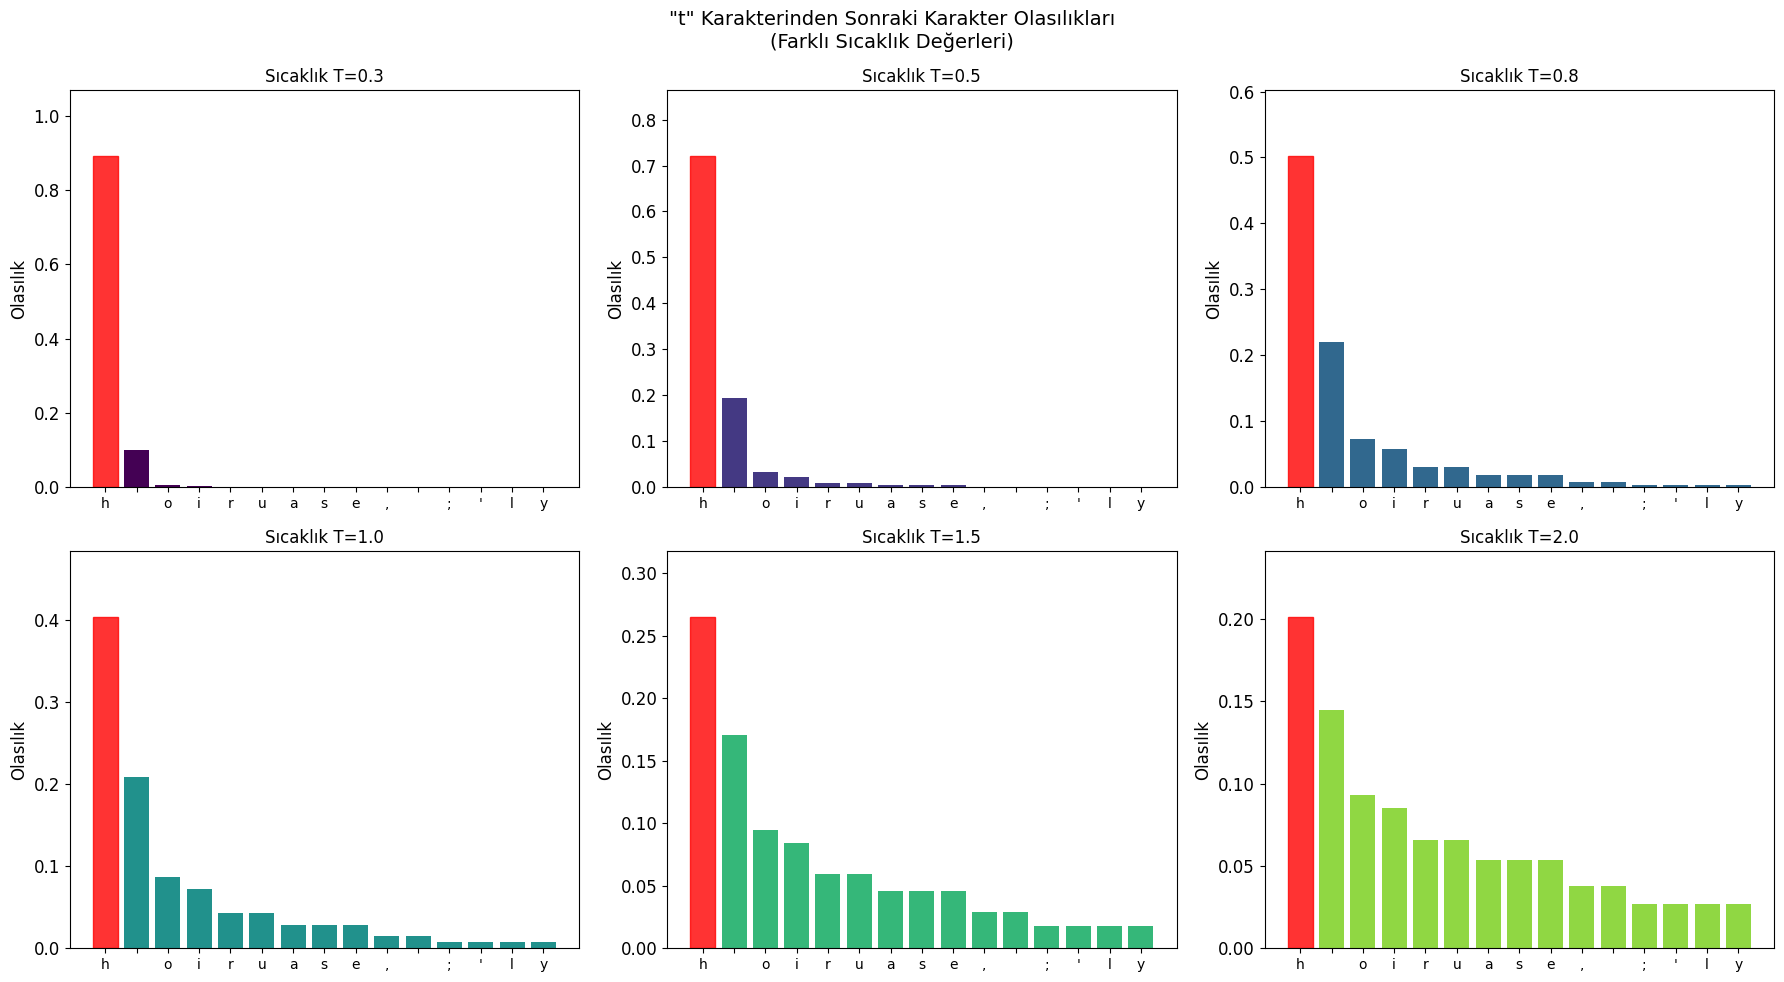


=== Shannon Entropy (Bellek) ===
Sıcaklık   Entropy        
-------------------------
0.3        0.3884         
0.5        0.9189         
0.8        1.6563         
1.0        1.9926         
1.5        2.4318         
2.0        2.6086         


In [13]:
# Olasılık dağılımlarını görselleştir

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# 'T' karakteri için olasılık dağılımı
sample_char = 't'
if sample_char in transition_probs:
    probs_dict = transition_probs[sample_char]
    chars = list(probs_dict.keys())
    probs = list(probs_dict.values())

    # Sırala (en yüksekten en düşüğe)
    sorted_indices = np.argsort(probs)[::-1][:15]  # En yüksek 15
    sorted_chars = [chars[i] for i in sorted_indices]
    sorted_probs = [probs[i] for i in sorted_indices]

    temperatures = [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]

    for idx, temp in enumerate(temperatures):
        ax = axes[idx]

        # Sıcaklık ile ölçekle
        scaled_probs = temperature_scale(sorted_probs, temp)

        # Bar chart oluştur
        bars = ax.bar(range(len(sorted_chars)), scaled_probs, color=plt.cm.viridis(idx/len(temperatures)))
        ax.set_xticks(range(len(sorted_chars)))
        ax.set_xticklabels(sorted_chars, fontsize=10)
        ax.set_title(f'Sıcaklık T={temp}', fontsize=12)
        ax.set_ylabel('Olasılık')
        ax.set_ylim(0, max(scaled_probs) * 1.2)

        # En yüksek olasılıklı karakteri vurgula
        max_idx = np.argmax(scaled_probs)
        bars[max_idx].set_color('red')
        bars[max_idx].set_alpha(0.8)

    plt.suptitle(f'"{sample_char}" Karakterinden Sonraki Karakter Olasılıkları\n(Farklı Sıcaklık Değerleri)', fontsize=14)
    plt.tight_layout()
    plt.show()

# Shannon entropy hesapla
print('\n=== Shannon Entropy (Bellek) ===')
print(f'{"Sıcaklık":<10} {"Entropy":<15}')
print('-' * 25)

for temp in [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]:
    if sample_char in transition_probs:
        probs = list(transition_probs[sample_char].values())
        scaled = temperature_scale(probs, temp)
        entropy = -np.sum(scaled * np.log(scaled + 1e-10))
        print(f'{temp:<10} {entropy:<15.4f}')

## 9. Sonuç

Bu notebook'ta öğrendiklerimiz:

1. **Bigram Modeli:** Karakterler arası geçiş olasılıklarını öğrenme
2. **Greedy Decoding:** Her adımda en yüksek olasılıklı seçeneği belirleme
3. **Sıcaklık (Temperature):** Olasılık dağılımını şekillendirme
    - Düşük sıcaklık: Odaklanmış, tekrarlayan
    - Yüksek sıcaklık: Çeşitli, rastgele
4. **Top-k Sampling:** En iyi k seçenek arasından örnekleme
5. **Top-p (Nucleus) Sampling:** Dinamik olarak olasılık eşiği belirleme

**Pratik Kullanım:**
- Yaratıcı yazım için: T=0.7-1.0, Top-p=0.9
- Odaklı cevaplar için: T=0.3-0.5, Greedy
- Çeşitli öneriler için: T=1.0-1.5, Top-k=10

**Sonraki Adımlar:**
- Daha büyük modeller (trigram, neural networks)
- Gerçek transformer modelleri (GPT, BERT)
- repetition penalty ve frequency penalty ekleme